In [1]:
import os
import time
import numpy as np
import random as rd
import tensorflow as tf

rd.seed(0)
np.random.seed(0)
tf.random.set_seed(0)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

2025-07-15 03:08:46.107228: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752548926.287865      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752548926.341062      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import pandas as pd

airx = pd.read_csv('/kaggle/input/stock-return-of-malaysia-companies/AirAsia X Stock Return History.csv')
pgas = pd.read_csv('/kaggle/input/stock-return-of-malaysia-companies/Petronas Gas Stock Return History.csv')
pubm = pd.read_csv('/kaggle/input/stock-return-of-malaysia-companies/Public Bank Stock Return History.csv')

T_airx = len(airx)
T_pgas = len(pgas)
T_pubm = len(pubm)

print('The number of data points in airx:', T_airx)
print('The number of data points in pgas:', T_pgas)
print('The number of data points in pubm:', T_pubm)

The number of data points in airx: 1227
The number of data points in pgas: 1228
The number of data points in pubm: 1225


In [3]:
airx['Date'] = pd.to_datetime(airx['Date'])
airx = airx.sort_values(by='Date')
airx.head().style.hide(axis='index')

Date,Return
2020-01-02 00:00:00,1.19%
2020-01-03 00:00:00,-1.64%
2020-01-06 00:00:00,0.48%
2020-01-07 00:00:00,0.00%
2020-01-08 00:00:00,0.24%


In [4]:
airx.at[1226, 'Return'] = '0.00%'
airx['Return'] = airx['Return'].str.replace('%', '').astype(float)
airx['t'] = (airx['Date'] - airx['Date'].min()).dt.days
airx.head().style.hide(axis='index')

Date,Return,t
2020-01-02 00:00:00,0.000000,0
2020-01-03 00:00:00,-1.640000,1
2020-01-06 00:00:00,0.480000,4
2020-01-07 00:00:00,0.000000,5
2020-01-08 00:00:00,0.240000,6


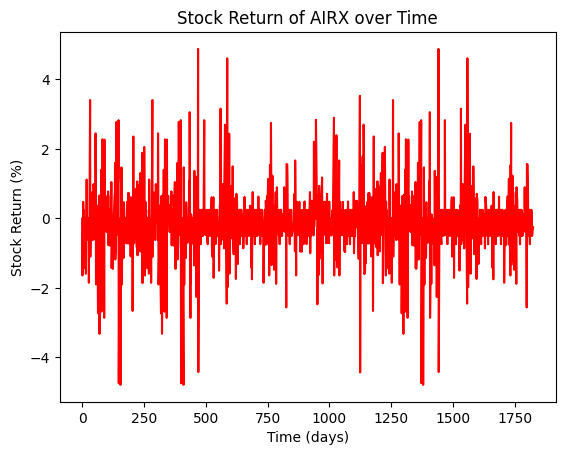

In [5]:
import matplotlib.pyplot as plt

plt.plot(airx['t'], airx['Return'], color='r')
plt.title('Stock Return of AIRX over Time')
plt.xlabel('Time (days)')
plt.ylabel('Stock Return (%)')
plt.show()

In [6]:
pgas['Date'] = pd.to_datetime(pgas['Date'])
pgas = pgas.sort_values(by='Date')
pgas.head().style.hide(axis='index')

Date,Return
2020-01-02 00:00:00,2.06%
2020-01-03 00:00:00,1.19%
2020-01-06 00:00:00,-1.64%
2020-01-07 00:00:00,0.48%
2020-01-08 00:00:00,0.00%


In [7]:
pgas.at[1227, 'Return'] = '0.00%'
pgas['Return'] = pgas['Return'].str.replace('%', '').astype(float)
pgas['t'] = (pgas['Date'] - pgas['Date'].min()).dt.days
pgas.head().style.hide(axis="index")

Date,Return,t
2020-01-02 00:00:00,0.000000,0
2020-01-03 00:00:00,1.190000,1
2020-01-06 00:00:00,-1.640000,4
2020-01-07 00:00:00,0.480000,5
2020-01-08 00:00:00,0.000000,6


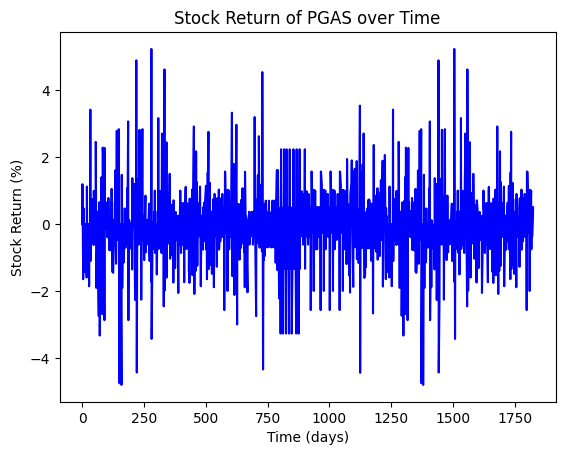

In [8]:
plt.plot(pgas['t'], pgas['Return'], color='b')
plt.title('Stock Return of PGAS over Time')
plt.xlabel('Time (days)')
plt.ylabel('Stock Return (%)')
plt.show()

In [9]:
pubm['Date'] = pd.to_datetime(pubm['Date'])
pubm = pubm.sort_values(by='Date')
pubm.head().style.hide(axis="index")

Date,Return
2020-01-02 00:00:00,2.37%
2020-01-03 00:00:00,0.30%
2020-01-06 00:00:00,-0.30%
2020-01-07 00:00:00,1.11%
2020-01-08 00:00:00,-2.58%


In [10]:
pubm.at[1224, 'Return'] = '0.00%'
pubm['Return'] = pubm['Return'].str.replace('%', '').astype(float)
pubm['t'] = (pubm['Date'] - pubm['Date'].min()).dt.days
pubm.head().style.hide(axis="index")

Date,Return,t
2020-01-02 00:00:00,0.000000,0
2020-01-03 00:00:00,0.300000,1
2020-01-06 00:00:00,-0.300000,4
2020-01-07 00:00:00,1.110000,5
2020-01-08 00:00:00,-2.580000,6


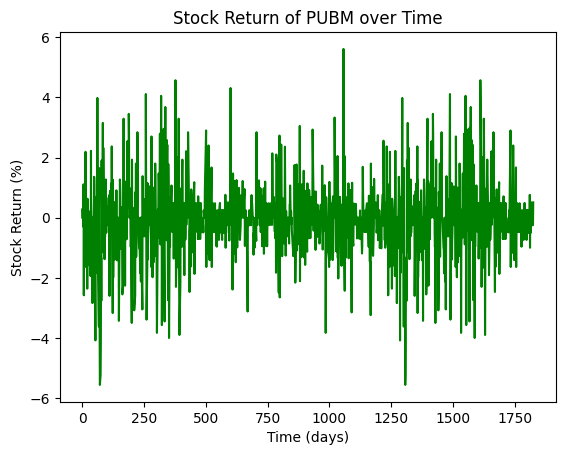

In [11]:
plt.plot(pubm['t'], pubm['Return'], color='g')
plt.title('Stock Return of PUBM over Time')
plt.xlabel('Time (days)')
plt.ylabel('Stock Return (%)')
plt.show()

In [12]:
def sliding_window(time_series, window_size):
    X = []
    y = []

    for t in range(len(time_series) - window_size + 1):
        X.append(time_series.iloc[t:t + window_size].values)

        if t <= len(time_series) - window_size - 1:
            y.append(time_series.iloc[t + window_size])
        else:
            y.append(y[-1])

    X = np.array(X).reshape(-1, window_size, 1)
    y = np.array(y).reshape(-1, 1)

    return X, y

In [13]:
X_airx, y_airx = sliding_window(airx['Return'], 60)
X_pgas, y_pgas = sliding_window(pgas['Return'], 60)
X_pubm, y_pubm = sliding_window(pubm['Return'], 60)

print('Size of X_airx:', len(X_airx))
print('Size of y_airx:', len(y_airx))

print('Size of X_pgas:', len(X_pgas))
print('Size of y_pgas:', len(y_pgas))

print('Size of X_pubm', len(X_pubm))
print('Size of y_pubm', len(y_pubm))

Size of X_airx: 1168
Size of y_airx: 1168
Size of X_pgas: 1169
Size of y_pgas: 1169
Size of X_pubm 1166
Size of y_pubm 1166


In [14]:
from sklearn.model_selection import train_test_split

X_airx_train, X_airx_test, y_airx_train, y_airx_test = train_test_split(X_airx, y_airx, test_size=0.2, 
                                                                        shuffle=False, random_state=0)

X_pgas_train, X_pgas_test, y_pgas_train, y_pgas_test = train_test_split(X_pgas, y_pgas, test_size=0.2, 
                                                                        shuffle=False, random_state=0)

X_pubm_train, X_pubm_test, y_pubm_train, y_pubm_test = train_test_split(X_pubm, y_pubm, test_size=0.2, 
                                                                        shuffle=False, random_state=0)

print('Size of airx_train:', len(X_airx_train))
print('Size of airx_test:', len(X_airx_test))

print('Size of pgas_train:', len(X_pgas_train))
print('Size of pgas_test:', len(X_pgas_test))

print('Size of pubm_train:', len(X_pubm_train))
print('Size of pubm_test:', len(X_pubm_test))

Size of airx_train: 934
Size of airx_test: 234
Size of pgas_train: 935
Size of pgas_test: 234
Size of pubm_train: 932
Size of pubm_test: 234


In [15]:
from sklearn.preprocessing import PowerTransformer, StandardScaler

yeo_airx = PowerTransformer(method='yeo-johnson')
norm_airx = StandardScaler()

yeo_pgas = PowerTransformer(method='yeo-johnson')
norm_pgas = StandardScaler()

yeo_pubm = PowerTransformer(method='yeo-johnson')
norm_pubm = StandardScaler()

In [16]:
X_airx_train = X_airx_train.reshape(X_airx_train.shape[0], -1)
X_airx_test = X_airx_test.reshape(X_airx_test.shape[0], -1)

X_airx_train = yeo_airx.fit_transform(X_airx_train)
X_airx_train = norm_airx.fit_transform(X_airx_train)

X_airx_test = yeo_airx.transform(X_airx_test)
X_airx_test = norm_airx.transform(X_airx_test)

y_airx_train = yeo_airx.fit_transform(y_airx_train)
y_airx_train = norm_airx.fit_transform(y_airx_train)

y_airx_test = yeo_airx.transform(y_airx_test)
y_airx_test = norm_airx.transform(y_airx_test)

X_airx_train = np.expand_dims(X_airx_train, axis=-1)
X_airx_test = np.expand_dims(X_airx_test, axis=-1)

In [17]:
X_pgas_train = X_pgas_train.reshape(X_pgas_train.shape[0], -1)
X_pgas_test = X_pgas_test.reshape(X_pgas_test.shape[0], -1)

X_pgas_train = yeo_pgas.fit_transform(X_pgas_train)
X_pgas_train = norm_pgas.fit_transform(X_pgas_train)

X_pgas_test = yeo_pgas.transform(X_pgas_test)
X_pgas_test = norm_pgas.transform(X_pgas_test)

y_pgas_train = yeo_pgas.fit_transform(y_pgas_train)
y_pgas_train = norm_pgas.fit_transform(y_pgas_train)

y_pgas_test = yeo_pgas.transform(y_pgas_test)
y_pgas_test = norm_pgas.transform(y_pgas_test)

X_pgas_train = np.expand_dims(X_pgas_train, axis=-1)
X_pgas_test = np.expand_dims(X_pgas_test, axis=-1)

In [18]:
X_pubm_train = X_pubm_train.reshape(X_pubm_train.shape[0], -1)
X_pubm_test = X_pubm_test.reshape(X_pubm_test.shape[0], -1)

X_pubm_train = yeo_pubm.fit_transform(X_pubm_train)
X_pubm_train = norm_pubm.fit_transform(X_pubm_train)

X_pubm_test = yeo_pubm.transform(X_pubm_test)
X_pubm_test = norm_pubm.transform(X_pubm_test)

y_pubm_train = yeo_pubm.fit_transform(y_pubm_train)
y_pubm_train = norm_pubm.fit_transform(y_pubm_train)

y_pubm_test = yeo_pubm.transform(y_pubm_test)
y_pubm_test = norm_pubm.transform(y_pubm_test)

X_pubm_train = np.expand_dims(X_pubm_train, axis=-1)
X_pubm_test = np.expand_dims(X_pubm_test, axis=-1)

In [19]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, concatenate
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

input_layer = Input(shape=(60, 1))

conv1 = Conv1D(filters=32, kernel_size=3, strides=1, padding='same', activation='linear', 
               kernel_initializer='he_normal')(input_layer)
conv2 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same', activation='linear', 
               kernel_initializer='he_normal')(input_layer)
conv3 = Conv1D(filters=32, kernel_size=7, strides=1, padding='same', activation='linear', 
               kernel_initializer='he_normal')(input_layer)
conv4 = Conv1D(filters=32, kernel_size=9, strides=1, padding='same', activation='linear', 
               kernel_initializer='he_normal')(input_layer)

concatenated = concatenate([conv1, conv2, conv3, conv4])

conv5 = Conv1D(filters=128, kernel_size=6, strides=2, padding='valid', activation='linear', 
               kernel_initializer='he_normal')(concatenated)

max_pool = MaxPooling1D(pool_size=5, strides=2)(conv5)

first_lstm = LSTM(128, return_sequences=True, kernel_initializer='he_normal', 
                  recurrent_initializer='orthogonal')(max_pool)
second_lstm = LSTM(128, return_sequences=False, kernel_initializer='he_normal', 
                   recurrent_initializer='orthogonal')(first_lstm)

hidden_layer = Dense(64, activation='linear', kernel_initializer='he_normal')(second_lstm)
output_layer = Dense(1, activation='linear', kernel_initializer='he_normal')(hidden_layer)

lr_scheduler_airx = CosineDecayRestarts(initial_learning_rate=3e-3, first_decay_steps=25, 
                                        t_mul=3.0, m_mul=0.6)

optimizer_airx = AdamW(learning_rate=lr_scheduler_airx, weight_decay=1e-6)

model_airx = Model(inputs=input_layer, outputs=output_layer)
model_airx.compile(optimizer=optimizer_airx, loss='log_cosh')

model_airx.summary()

I0000 00:00:1752548940.307328      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 60, 1)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 60, 32)         │            128 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 60, 32)         │            192 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 60, 32)         │            256 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 60, 32)         │            320 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 60, 128)        │              0 │ conv1d[0][0],          │
│                           │                        │                │ conv1d_1[0][0],        │
│                           │                        │                │ conv1d_2[0][0],        │
│                           │                        │                │ conv1d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 28, 128)        │         98,432 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 12, 128)        │              0 │ conv1d_4[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 12, 128)        │        131,584 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 128)            │        131,584 │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 64)             │          8,256 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │             65 │ dense[0][0]            │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 370,817 (1.41 MB)

 Trainable params: 370,817 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
start_time = time.time()

train_log_airx = model_airx.fit(X_airx_train, y_airx_train, epochs=100, batch_size=32,
                                validation_data=(X_airx_test, y_airx_test))

end_time = time.time()

training_time_airx = end_time - start_time

print('Training time:', training_time_airx)

Epoch 1/100


2025-07-15 03:09:01.757965: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1752548949.569165      91 cuda_dnn.cc:529] Loaded cuDNN version 90300


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6184

2025-07-15 03:09:11.580190: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.6124 - val_loss: 0.2098
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2968 - val_loss: 0.2087
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2886 - val_loss: 0.2035
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2832 - val_loss: 0.2006
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2793 - val_loss: 0.1994
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2756 - val_loss: 0.1873
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2558 - val_loss: 0.1730
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2303 - val_loss: 0.1669
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2138 - val_loss: 0.1505
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1933 - val_loss: 0.1469
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1806 - val_loss: 0.1604
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.

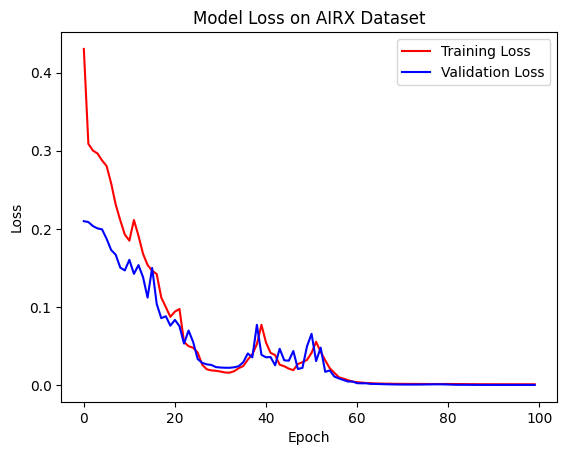

In [21]:
plt.plot(train_log_airx.history['loss'], color='r', label='Training Loss')
plt.plot(train_log_airx.history['val_loss'], color='b', label='Validation Loss')
plt.title('Model Loss on AIRX Dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
y_airx_train = norm_airx.inverse_transform(y_airx_train)
y_airx_train = yeo_airx.inverse_transform(y_airx_train)

y_airx_test = norm_airx.inverse_transform(y_airx_test)
y_airx_test = yeo_airx.inverse_transform(y_airx_test)

In [23]:
y_airx_train_pred = model_airx.predict(X_airx_train)
y_airx_train_pred = norm_airx.inverse_transform(y_airx_train_pred)
y_airx_train_pred = yeo_airx.inverse_transform(y_airx_train_pred)

y_airx_test_pred = model_airx.predict(X_airx_test)
y_airx_test_pred = norm_airx.inverse_transform(y_airx_test_pred)
y_airx_test_pred = yeo_airx.inverse_transform(y_airx_test_pred)

2025-07-15 03:09:44.511786: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [24]:
future_steps = 240

current_window = X_airx_test[-1].reshape(1, 60, 1)

airx_future_preds = []

for step in range(future_steps):        
    next_pred = model_airx.predict(current_window)
    airx_future_preds.append(next_pred[0, 0])

    current_window = current_window.reshape(-1, 1)
    current_window = norm_airx.inverse_transform(current_window)
    current_window = yeo_airx.inverse_transform(current_window)
    
    current_window = np.roll(current_window, -1, axis=0)
    current_window[-1, 0] = next_pred[0, 0]
    
    current_window = yeo_airx.transform(current_window)
    current_window = norm_airx.transform(current_window)
    current_window = current_window.reshape(1, 60, 1)

airx_future_preds = np.array(airx_future_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

2025-07-15 03:09:49.560122: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

2025-07-15 03:09:54.567925: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

2025-07-15 03:09:59.598886: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


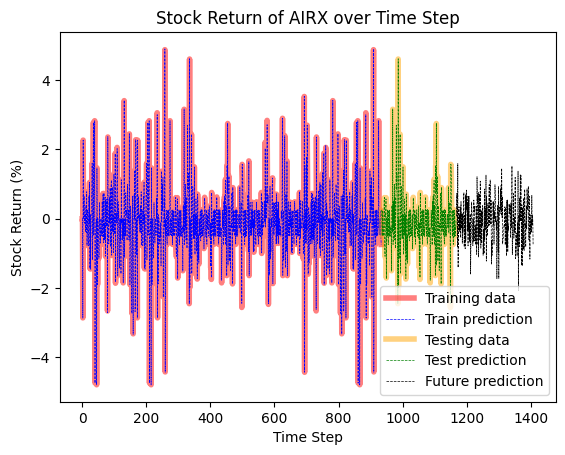

In [25]:
plt.plot(y_airx_train, linewidth=4, alpha=0.5, color='r', label='Training data')
plt.plot(y_airx_train_pred, linewidth=0.5, color='b', linestyle='--', label='Train prediction')

plt.plot(range(len(y_airx_train), len(y_airx)), y_airx_test, linewidth=4, alpha=0.5, color='orange', 
         label='Testing data')
plt.plot(range(len(y_airx_train), len(y_airx)), y_airx_test_pred, linewidth=0.5, color='g',
         linestyle='--', label='Test prediction')

plt.plot(range(len(y_airx), len(y_airx) + 240), airx_future_preds, linewidth=0.5, color='black',
        linestyle='--', label='Future prediction')

plt.title('Stock Return of AIRX over Time Step')
plt.xlabel('Time Step')
plt.ylabel('Stock Return (%)')
plt.legend()
plt.show()

In [26]:
def mean_directional_accuracy(y_true, y_pred):
    return np.mean((np.sign(y_true) == np.sign(y_pred)).astype(int))

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_airx = mean_absolute_error(y_airx_test, y_airx_test_pred)
mse_airx = mean_squared_error(y_airx_test, y_airx_test_pred)
rmse_airx = np.sqrt(mse_airx)
mda_airx = mean_directional_accuracy(y_airx_test, y_airx_test_pred)

print('MAE of AIRX:', mae_airx)
print('MSE of AIRX:', mse_airx)
print('RMSE of AIRX:', rmse_airx)
print('MDA of AIRX:', mda_airx)

MAE of AIRX: 0.013967238939725445
MSE of AIRX: 0.0008476350141685417
RMSE of AIRX: 0.029114172050198193
MDA of AIRX: 0.8717948717948718


In [28]:
from tensorflow.keras.models import clone_model

model_pgas = clone_model(model_airx)

lr_scheduler_pgas = CosineDecayRestarts(initial_learning_rate=3e-3, first_decay_steps=25, t_mul=3.0, 
                                        m_mul=0.6)

optimizer_pgas = AdamW(learning_rate=lr_scheduler_pgas, weight_decay=1e-6)

model_pgas.compile(optimizer=optimizer_pgas, loss='log_cosh')

model_pgas.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor (InputLayer) │ (None, 60, 1)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 60, 32)         │            128 │ keras_tensor[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 60, 32)         │            192 │ keras_tensor[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 60, 32)         │            256 │ keras_tensor[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 60, 32)         │            320 │ keras_tensor[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 60, 128)        │              0 │ conv1d[0][0],          │
│                           │                        │                │ conv1d_1[0][0],        │
│                           │                        │                │ conv1d_2[0][0],        │
│                           │                        │                │ conv1d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 28, 128)        │         98,432 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 12, 128)        │              0 │ conv1d_4[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 12, 128)        │        131,584 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 128)            │        131,584 │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 64)             │          8,256 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │             65 │ dense[0][0]            │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 370,817 (1.41 MB)

 Trainable params: 370,817 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
start_time = time.time()

train_log_pgas = model_pgas.fit(X_pgas_train, y_pgas_train, epochs=100, batch_size=32,
                                validation_data=(X_pgas_test, y_pgas_test))

end_time = time.time()

training_time_pgas = end_time - start_time

print('Training time:', training_time_pgas)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6795

2025-07-15 03:10:10.706541: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.6738 - val_loss: 0.2633
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2939 - val_loss: 0.2571
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2813 - val_loss: 0.2545
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2745 - val_loss: 0.2474
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2773 - val_loss: 0.2379
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2695 - val_loss: 0.2241
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2586 - val_loss: 0.2105
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2439 - val_loss: 0.1982
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2246 - val_loss: 0.1798
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2045 - val_loss: 0.1739
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1964 - val_loss: 0.1692
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2

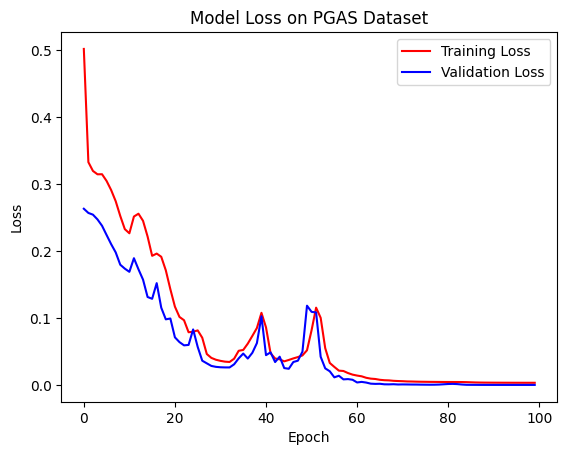

In [30]:
plt.plot(train_log_pgas.history['loss'], color='r', label='Training Loss')
plt.plot(train_log_pgas.history['val_loss'], color='b', label='Validation Loss')
plt.title('Model Loss on PGAS Dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [31]:
y_pgas_train = norm_pgas.inverse_transform(y_pgas_train)
y_pgas_train = yeo_pgas.inverse_transform(y_pgas_train)

y_pgas_test = norm_pgas.inverse_transform(y_pgas_test)
y_pgas_test = yeo_pgas.inverse_transform(y_pgas_test)

In [32]:
y_pgas_train_pred = model_pgas.predict(X_pgas_train)
y_pgas_train_pred = norm_pgas.inverse_transform(y_pgas_train_pred)
y_pgas_train_pred = yeo_pgas.inverse_transform(y_pgas_train_pred)

y_pgas_test_pred = model_pgas.predict(X_pgas_test)
y_pgas_test_pred = norm_pgas.inverse_transform(y_pgas_test_pred)
y_pgas_test_pred = yeo_pgas.inverse_transform(y_pgas_test_pred)

2025-07-15 03:10:44.629357: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [33]:
future_steps = 240

current_window = X_pgas_test[-1].reshape(1, 60, 1)

pgas_future_preds = []

for step in range(future_steps):        
    next_pred = model_pgas.predict(current_window)
    pgas_future_preds.append(next_pred[0, 0])

    current_window = current_window.reshape(-1, 1)
    current_window = norm_pgas.inverse_transform(current_window)
    current_window = yeo_pgas.inverse_transform(current_window)
    
    current_window = np.roll(current_window, -1, axis=0)
    current_window[-1, 0] = next_pred[0, 0]
    
    current_window = yeo_pgas.transform(current_window)
    current_window = norm_pgas.transform(current_window)
    current_window = current_window.reshape(1, 60, 1)

pgas_future_preds = np.array(pgas_future_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

2025-07-15 03:10:49.636093: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

2025-07-15 03:10:54.693847: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

2025-07-15 03:10:59.740322: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

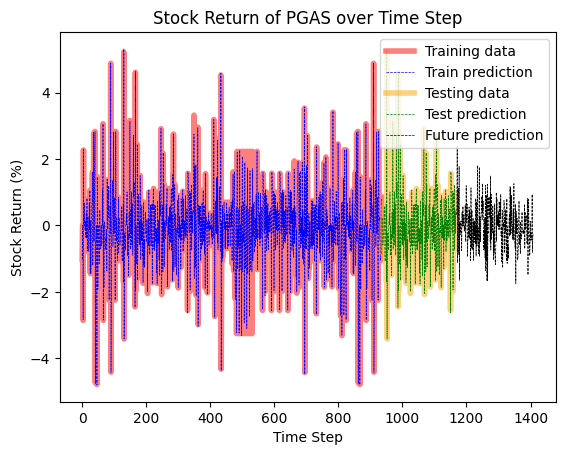

In [34]:
plt.plot(y_pgas_train, linewidth=4, alpha=0.5, color='r', label='Training data')
plt.plot(y_pgas_train_pred, linewidth=0.5, color='b', linestyle='--', label='Train prediction')

plt.plot(range(len(y_pgas_train), len(y_pgas)), y_pgas_test, linewidth=4, alpha=0.5, color='orange', 
         label='Testing data')
plt.plot(range(len(y_pgas_train), len(y_pgas)), y_pgas_test_pred, linewidth=0.5, color='g',
         linestyle='--', label='Test prediction')

plt.plot(range(len(y_pgas), len(y_pgas) + 240), pgas_future_preds, linewidth=0.5, color='black',
        linestyle='--', label='Future prediction')

plt.title('Stock Return of PGAS over Time Step')
plt.xlabel('Time Step')
plt.ylabel('Stock Return (%)')
plt.legend()
plt.show()

In [35]:
mae_pgas = mean_absolute_error(y_pgas_test, y_pgas_test_pred)
mse_pgas = mean_squared_error(y_pgas_test, y_pgas_test_pred)
rmse_pgas = np.sqrt(mse_pgas)
mda_pgas = mean_directional_accuracy(y_pgas_test, y_pgas_test_pred)

print('MAE of PGAS:', mae_pgas)
print('MSE of PGAS:', mse_pgas)
print('RMSE of PGAS:', rmse_pgas)
print('MDA of PGAS:', mda_pgas)

MAE of PGAS: 0.023411043362739796
MSE of PGAS: 0.0012838403777173896
RMSE of PGAS: 0.03583071835335414
MDA of PGAS: 0.9316239316239316


In [36]:
model_pubm = clone_model(model_airx)

lr_scheduler_pubm = CosineDecayRestarts(initial_learning_rate=4e-3, first_decay_steps=25, t_mul=3.0, 
                                        m_mul=0.5)

optimizer_pubm = AdamW(learning_rate=lr_scheduler_pubm, weight_decay=1e-6)

model_pubm.compile(optimizer=optimizer_pubm, loss='log_cosh')

model_pubm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor (InputLayer) │ (None, 60, 1)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 60, 32)         │            128 │ keras_tensor[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 60, 32)         │            192 │ keras_tensor[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 60, 32)         │            256 │ keras_tensor[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 60, 32)         │            320 │ keras_tensor[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 60, 128)        │              0 │ conv1d[0][0],          │
│                           │                        │                │ conv1d_1[0][0],        │
│                           │                        │                │ conv1d_2[0][0],        │
│                           │                        │                │ conv1d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 28, 128)        │         98,432 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 12, 128)        │              0 │ conv1d_4[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 12, 128)        │        131,584 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 128)            │        131,584 │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 64)             │          8,256 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │             65 │ dense[0][0]            │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 370,817 (1.41 MB)

 Trainable params: 370,817 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
start_time = time.time()

train_log_pubm = model_pubm.fit(X_pubm_train, y_pubm_train, epochs=100, batch_size=32,
                                validation_data=(X_pubm_test, y_pubm_test))

end_time = time.time()

training_time_pubm = end_time - start_time

print('Training time:', training_time_pubm)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4780

2025-07-15 03:11:10.466195: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.4754 - val_loss: 0.3714
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3368 - val_loss: 0.3440
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3230 - val_loss: 0.3303
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3217 - val_loss: 0.3435
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3100 - val_loss: 0.3057
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2952 - val_loss: 0.2930
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2789 - val_loss: 0.2774
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2528 - val_loss: 0.2614
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2250 - val_loss: 0.2509
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2030 - val_loss: 0.2260
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1993 - val_loss: 0.2150
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2

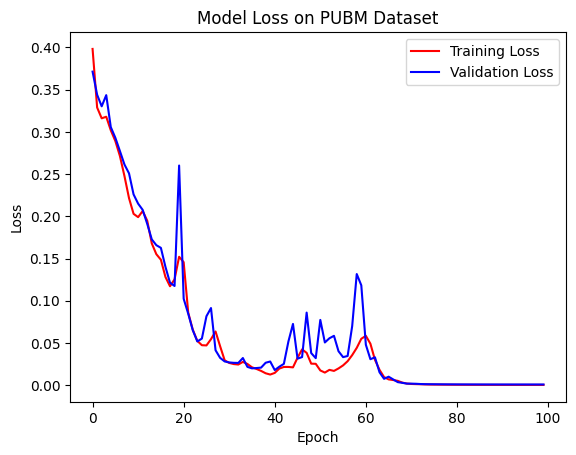

In [38]:
plt.plot(train_log_pubm.history['loss'], color='r', label='Training Loss')
plt.plot(train_log_pubm.history['val_loss'], color='b', label='Validation Loss')
plt.title('Model Loss on PUBM Dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
y_pubm_train = norm_pubm.inverse_transform(y_pubm_train)
y_pubm_train = yeo_pubm.inverse_transform(y_pubm_train)

y_pubm_test = norm_pubm.inverse_transform(y_pubm_test)
y_pubm_test = yeo_pubm.inverse_transform(y_pubm_test)

In [40]:
y_pubm_train_pred = model_pubm.predict(X_pubm_train)
y_pubm_train_pred = norm_pubm.inverse_transform(y_pubm_train_pred)
y_pubm_train_pred = yeo_pubm.inverse_transform(y_pubm_train_pred)

y_pubm_test_pred = model_pubm.predict(X_pubm_test)
y_pubm_test_pred = norm_pubm.inverse_transform(y_pubm_test_pred)
y_pubm_test_pred = yeo_pubm.inverse_transform(y_pubm_test_pred)

2025-07-15 03:11:44.388214: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [41]:
future_steps = 240

current_window = X_pubm_test[-1].reshape(1, 60, 1)

pubm_future_preds = []

for step in range(future_steps):        
    next_pred = model_pubm.predict(current_window)
    pubm_future_preds.append(next_pred[0, 0])

    current_window = current_window.reshape(-1, 1)
    current_window = norm_pubm.inverse_transform(current_window)
    current_window = yeo_pubm.inverse_transform(current_window)
    
    current_window = np.roll(current_window, -1, axis=0)
    current_window[-1, 0] = next_pred[0, 0]
    
    current_window = yeo_pubm.transform(current_window)
    current_window = norm_pubm.transform(current_window)
    current_window = current_window.reshape(1, 60, 1)

pubm_future_preds = np.array(pubm_future_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

2025-07-15 03:11:49.399768: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

2025-07-15 03:11:54.403609: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

2025-07-15 03:11:59.413959: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


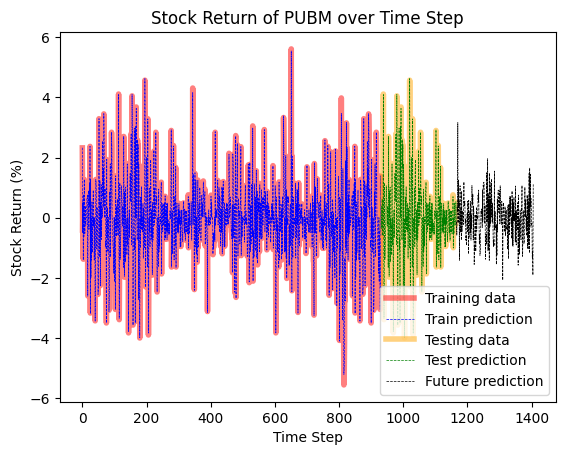

In [42]:
plt.plot(y_pubm_train, linewidth=4, alpha=0.5, color='r', label='Training data')
plt.plot(y_pubm_train_pred, linewidth=0.5, color='b', linestyle='--', label='Train prediction')

plt.plot(range(len(y_pubm_train), len(y_pubm)), y_pubm_test, linewidth=4, alpha=0.5, color='orange', 
         label='Testing data')
plt.plot(range(len(y_pubm_train), len(y_pubm)), y_pubm_test_pred, linewidth=0.5, color='g',
         linestyle='--', label='Test prediction')

plt.plot(range(len(y_pubm), len(y_pubm) + 240), pubm_future_preds, linewidth=0.5, color='black',
        linestyle='--', label='Future prediction')

plt.title('Stock Return of PUBM over Time Step')
plt.xlabel('Time Step')
plt.ylabel('Stock Return (%)')
plt.legend()
plt.show()

In [43]:
mae_pubm = mean_absolute_error(y_pubm_test, y_pubm_test_pred)
mse_pubm = mean_squared_error(y_pubm_test, y_pubm_test_pred)
rmse_pubm = np.sqrt(mse_pubm)
mda_pubm = mean_directional_accuracy(y_pubm_test, y_pubm_test_pred)

print('MAE of PUBM:', mae_pubm)
print('MSE of PUBM:', mse_pubm)
print('RMSE of PUBM:', rmse_pubm)
print('MDA of PUBM:', mda_pubm)

MAE of PUBM: 0.020049304921402916
MSE of PUBM: 0.0027933112474714597
RMSE of PUBM: 0.05285178566019751
MDA of PUBM: 0.8717948717948718


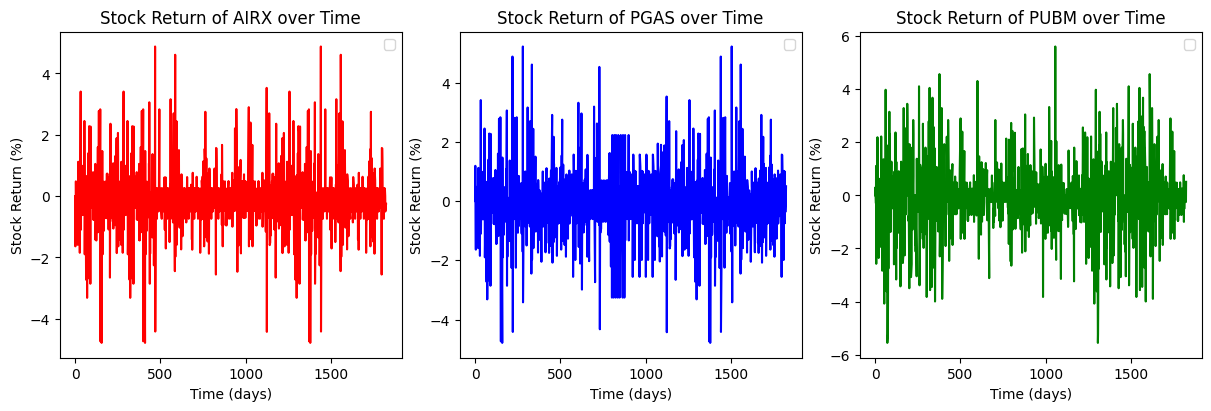

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("Stock Return of AIRX over Time")
axes[1].set_title("Stock Return of PGAS over Time")
axes[2].set_title("Stock Return of PUBM over Time")

axes[0].plot(airx['t'], airx['Return'], color='r')
axes[1].plot(pgas['t'], pgas['Return'], color='b')
axes[2].plot(pubm['t'], pubm['Return'], color='g')

for axis in axes:
    axis.set_xlabel('Time (days)')
    axis.set_ylabel('Stock Return (%)') 
    axis.legend()

fig.set_constrained_layout(True)
plt.show()

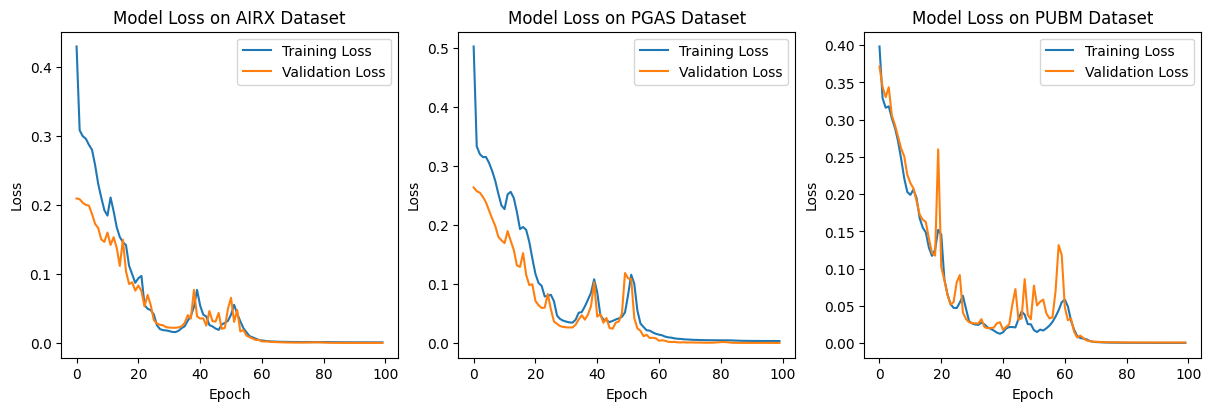

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("Model Loss on AIRX Dataset")
axes[1].set_title("Model Loss on PGAS Dataset")
axes[2].set_title("Model Loss on PUBM Dataset")

axes[0].plot(train_log_airx.history['loss'], label='Training Loss')
axes[0].plot(train_log_airx.history['val_loss'], label='Validation Loss')
axes[1].plot(train_log_pgas.history['loss'], label='Training Loss')
axes[1].plot(train_log_pgas.history['val_loss'], label='Validation Loss')
axes[2].plot(train_log_pubm.history['loss'], label='Training Loss')
axes[2].plot(train_log_pubm.history['val_loss'], label='Validation Loss')

for axis in axes:
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Loss') 
    axis.legend()

fig.set_constrained_layout(True)
plt.show()

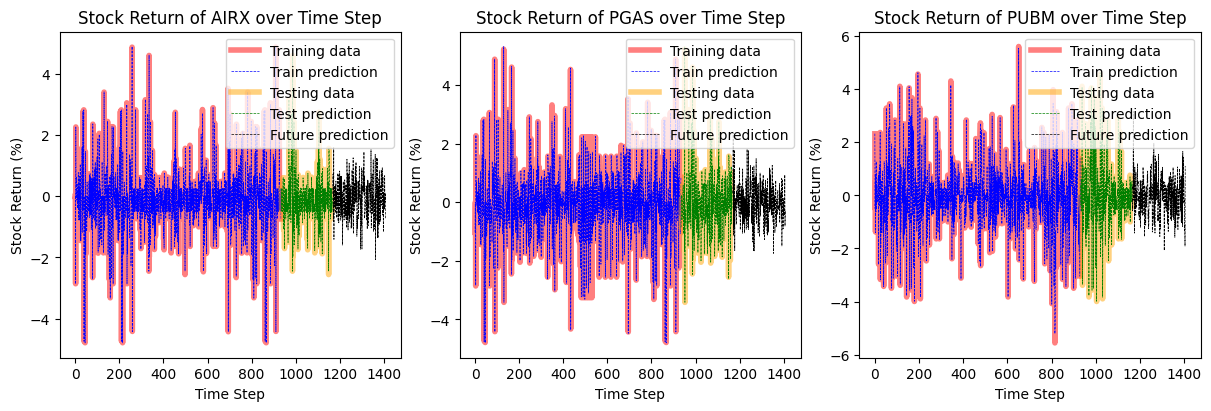

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(y_airx_train, linewidth=4, alpha=0.5, color='r', label='Training data')
axes[0].plot(y_airx_train_pred, linewidth=0.5, color='b', linestyle='--', label='Train prediction')

axes[0].plot(range(len(y_airx_train), len(y_airx)), y_airx_test, linewidth=4, alpha=0.5, color='orange', 
         label='Testing data')
axes[0].plot(range(len(y_airx_train), len(y_airx)), y_airx_test_pred, linewidth=0.5, color='g',
         linestyle='--', label='Test prediction')

axes[0].plot(range(len(y_airx), len(y_airx) + 240), airx_future_preds, linewidth=0.5, color='black',
        linestyle='--', label='Future prediction')

axes[1].plot(y_pgas_train, linewidth=4, alpha=0.5, color='r', label='Training data')
axes[1].plot(y_pgas_train_pred, linewidth=0.5, color='b', linestyle='--', label='Train prediction')

axes[1].plot(range(len(y_pgas_train), len(y_pgas)), y_pgas_test, linewidth=4, alpha=0.5, color='orange', 
         label='Testing data')
axes[1].plot(range(len(y_pgas_train), len(y_pgas)), y_pgas_test_pred, linewidth=0.5, color='g',
         linestyle='--', label='Test prediction')

axes[1].plot(range(len(y_pgas), len(y_pgas) + 240), pgas_future_preds, linewidth=0.5, color='black',
        linestyle='--', label='Future prediction')

axes[2].plot(y_pubm_train, linewidth=4, alpha=0.5, color='r', label='Training data')
axes[2].plot(y_pubm_train_pred, linewidth=0.5, color='b', linestyle='--', label='Train prediction')

axes[2].plot(range(len(y_pubm_train), len(y_pubm)), y_pubm_test, linewidth=4, alpha=0.5, color='orange', 
         label='Testing data')
axes[2].plot(range(len(y_pubm_train), len(y_pubm)), y_pubm_test_pred, linewidth=0.5, color='g',
         linestyle='--', label='Test prediction')

axes[2].plot(range(len(y_pubm), len(y_pubm) + 240), pubm_future_preds, linewidth=0.5, color='black',
        linestyle='--', label='Future prediction')

axes[0].set_title("Stock Return of AIRX over Time Step")
axes[1].set_title("Stock Return of PGAS over Time Step")
axes[2].set_title("Stock Return of PUBM over Time Step")

for axis in axes:
    axis.set_xlabel('Time Step')
    axis.set_ylabel('Stock Return (%)') 
    axis.legend()

fig.set_constrained_layout(True)
plt.show()

In [47]:
average_mae = (mae_airx + mae_pgas + mae_pubm) / 3
average_mse = (mse_airx + mse_pgas + mse_pubm) / 3
average_rmse = (rmse_airx + rmse_pgas + rmse_pubm) / 3
average_mda = (mda_airx + mda_pgas + mda_pubm) / 3
average_training_time = (training_time_airx + training_time_pgas + training_time_pubm) / 3

print('Average MAE:', average_mae)
print('Average MSE:', average_mse)
print('Average RMSE:', average_rmse)
print('Average MDA:', average_mda)
print('Average Training Time:', average_training_time)

Average MAE: 0.01914252907462272
Average MSE: 0.0016415955464524634
Average RMSE: 0.03926555868791662
Average MDA: 0.8917378917378919
Average Training Time: 42.162130196889244


In [48]:
evaluations = {
    'Company': ['AIRX', 'PGAS', 'PUBM', 'Average'],
    'MAE': [mae_airx, mae_pgas, mae_pubm, average_mae],
    'MSE': [mse_airx, mse_pgas, mse_pubm, average_mse],
    'RMSE': [rmse_airx, rmse_pgas, rmse_pubm, average_rmse],
    'MDA': [mda_airx, mda_pgas, mda_pubm, average_mda],
    'Training Time (s)': 
    [training_time_airx, training_time_pgas, training_time_pubm, average_training_time]
}

df = pd.DataFrame(evaluations)
df.head().style.hide(axis="index")

Company,MAE,MSE,RMSE,MDA,Training Time (s)
AIRX,0.013967,0.000848,0.029114,0.871795,42.625024
PGAS,0.023411,0.001284,0.035831,0.931624,42.105969
PUBM,0.020049,0.002793,0.052852,0.871795,41.755398
Average,0.019143,0.001642,0.039266,0.891738,42.162130
